|<h2>Course:</h2>|<h1><a href="https://derivingsystems.com/course.html" target="_blank">Build your own vLLM: inference engines from the memory system up</a></h1>|
|-|:-:|
|<h2>Part 7:</h2>|<h1>Modern vLLM<h1>|
|<h2>Section:</h2>|<h1>Guided decoding<h1>|
|<h2>Lecture:</h2>|<h1><b>Masking the logits that cannot legally come next<b></h1>|

<br>

<h5><b>Course repo:</b> <a href="https://github.com/Venugopalan2610/vllm-from-scratch" target="_blank">github.com/Venugopalan2610/vllm-from-scratch</a></h5>
<h5><b>The derivations:</b> <a href="https://derivingsystems.com" target="_blank">derivingsystems.com</a></h5>
<i>The notebooks build the intuition. The ladder in app/ makes you build the thing.</i>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# Make the illegal tokens impossible

If you ask a model politely for JSON, you get JSON most of the time. "Most of
the time" is not a schema.

There is a different method. Make the invalid output unreachable. At every
step, set the logits of all tokens that cannot legally come next to negative
infinity.

In [2]:
import sys
from pathlib import Path
ROOT = next(folder for folder in [Path.cwd(), *Path.cwd().parents]
            if (folder/'cudalib').is_dir())
sys.path.insert(0, str(ROOT))
from tests.helpers import json_prefix_state
for text in ['{"a"', '{"a":', '{"a": 1}', '{"a": 1},', '{"a" 1}', '[1, 2', '[1, 2]']:
  print(f'{text!r:<14} {json_prefix_state(text)}')

'{"a"'         prefix
'{"a":'        prefix
'{"a": 1}'     valid
'{"a": 1},'    invalid
'{"a" 1}'      invalid
'[1, 2'        prefix
'[1, 2]'       valid


`prefix` means it could still become valid. `invalid` means no continuation
can rescue it. That second answer is what lets you mask: a token is legal at
this step exactly when appending it leaves you in `prefix` or `valid`.

### The mask, on a tiny vocabulary

In [3]:
VOCAB = ['{', '}', '[', ']', '"', ':', ',', 'a', 'b', '1', '2', ' ', 'true', 'null']

def legal_mask(prefix):
  """-> for each token of VOCAB, True if prefix + token can still become valid."""
  return [json_prefix_state(prefix + token) != 'invalid' for token in VOCAB]

for prefix in ['', '{', '{"', '{"a', '{"a"', '{"a":', '{"a": 1']:
  allowed = [token for token, is_legal in zip(VOCAB, legal_mask(prefix)) if is_legal]
  print(f'{prefix!r:<10} -> {len(allowed):>2}/{len(VOCAB)} legal: {allowed}')

''         ->  8/14 legal: ['{', '[', '"', '1', '2', ' ', 'true', 'null']
'{'        ->  3/14 legal: ['}', '"', ' ']
'{"'       -> 14/14 legal: ['{', '}', '[', ']', '"', ':', ',', 'a', 'b', '1', '2', ' ', 'true', 'null']
'{"a'      -> 14/14 legal: ['{', '}', '[', ']', '"', ':', ',', 'a', 'b', '1', '2', ' ', 'true', 'null']
'{"a"'     ->  2/14 legal: [':', ' ']
'{"a":'    ->  8/14 legal: ['{', '[', '"', '1', '2', ' ', 'true', 'null']
'{"a": 1'  ->  5/14 legal: ['}', ',', '1', '2', ' ']


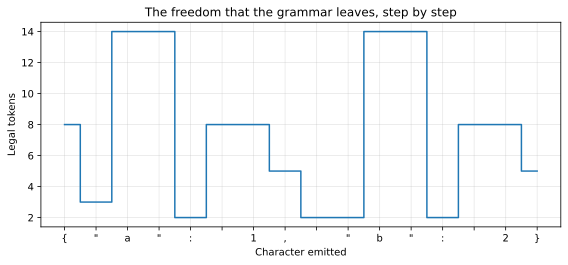

tightest step: 2 of 14 tokens legal
At those steps the model does not choose. The grammar does.


In [4]:
TARGET = '{"a": 1, "b": 2}'
legal_counts = [sum(legal_mask(TARGET[:position])) for position in range(len(TARGET))]
plt.figure(figsize=(8,3.8))
plt.step(range(len(legal_counts)), legal_counts, where='mid')
plt.xticks(range(len(legal_counts)), list(TARGET))
plt.ylabel('Legal tokens')
plt.xlabel('Character emitted')
plt.title('The freedom that the grammar leaves, step by step')
plt.grid(alpha=.3)
plt.tight_layout()
plt.show()
print(f'tightest step: {min(legal_counts)} of {len(VOCAB)} tokens legal')
print('At those steps the model does not choose. The grammar does.')

# The two hard parts, and neither one is the grammar

**Tokenizer alignment.** A real vocabulary does not hold characters. One token
is `'": '`. Another is `'", "'`.

A token is legal only if the full string that it expands to keeps the prefix
valid. So the FSM must advance by several characters at one time. Every
practical bug in guided decoding is here.

**The mask must stay off the critical path.** To build the mask, you ask for
each of 150,000 tokens if it is legal to append it.

In [5]:
import time
VOCAB_SIZE = 151936                # Qwen3
PREFIX = '{"name": "Ada", "age": 3'
REPEATS = 1000
start = time.perf_counter()
for _ in range(REPEATS):
  for token in VOCAB:
    json_prefix_state(PREFIX + token)
check_us = (time.perf_counter() - start) / (REPEATS * len(VOCAB)) * 1e6
mask_ms = VOCAB_SIZE * check_us / 1000
print(f'one prefix check:                      {check_us:7.2f} us')
print(f'a check of each token, for each step:  {mask_ms:7.1f} ms')
print('\nCompare that with the decode step time that you measured in Part 5.')

one prefix check:                         3.33 us
a check of each token, for each step:    505.8 ms

Compare that with the decode step time that you measured in Part 5.


So nobody uses that method. The FSM has a **finite** number of states, and the
state gives the mask completely. Precompute one mask for each state and cache
it. A step then becomes a lookup and a bitwise operation.

Then build the mask for the next state on another thread, while the GPU runs
the current step. The mask is ready before anybody asks for it.

That is the shape of stage 19. The grammar is the easy part. The tokenizer is
the difficult part. The scheduling is the part that makes the mask free.

    ./vc guide 19